
# **Project Title**

# News Category Classification Using LSTM

# **Objective**

### Build a multiclass text classification model that predicts the news category from a news article title/description.

Categories:

1.World

2.Sports

3.Business

4.Science/Technology

# Step 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Step 2: Load Dataset

In [ ]:
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

train_df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


# Step 3: Prepare Text

In [ ]:
train_df["text"] = train_df["Title"] + " " + train_df["Description"]
test_df["text"] = test_df["Title"] + " " + test_df["Description"]

X_train = train_df["text"]
X_test = test_df["text"]

y_train = train_df["Class Index"] - 1
y_test = test_df["Class Index"] - 1

# Step 4: Document Length Distribution

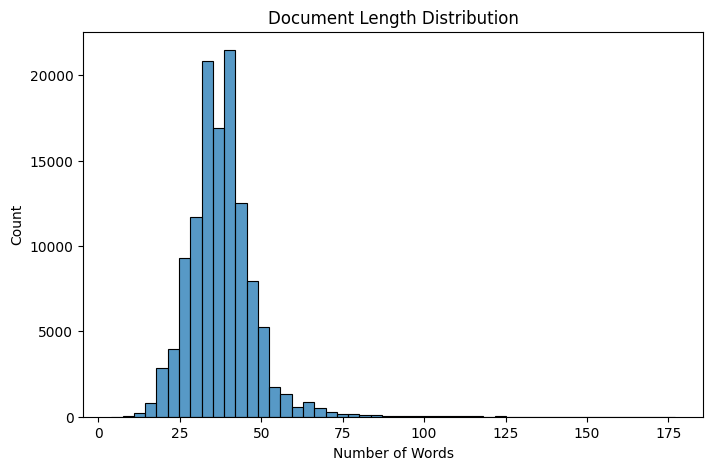

In [ ]:
lengths = X_train.apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(lengths, bins=50)
plt.title("Document Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

**Baseline Model (TF-IDF + Logistic Regression)**
# Step 5: TF-IDF

In [ ]:
tfidf = TfidfVectorizer(
    max_features=20000,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Step 6: Train Baseline

In [ ]:
baseline = LogisticRegression(max_iter=1000)

baseline.fit(X_train_tfidf, y_train)

pred_baseline = baseline.predict(X_test_tfidf)

# Step 7: Evaluate Baseline

In [ ]:
print(classification_report(
    y_test,
    pred_baseline
))

              precision    recall  f1-score   support

           0       0.93      0.90      0.92      1900
           1       0.96      0.98      0.97      1900
           2       0.88      0.88      0.88      1900
           3       0.89      0.89      0.89      1900

    accuracy                           0.92      7600
   macro avg       0.91      0.92      0.91      7600
weighted avg       0.91      0.92      0.91      7600



# Macro F1

In [ ]:
baseline_f1 = f1_score(
    y_test,
    pred_baseline,
    average='macro'
)

print("Baseline Macro F1:", baseline_f1)

Baseline Macro F1: 0.9148067584683681


# **LSTM Model**

# Step 8: Tokenization

In [ ]:
MAX_WORDS = 30000
MAX_LEN = 100

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

# Step 9: Convert Text to Sequences

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post'
)

# Step 10: One-Hot Labels

In [ ]:
y_train_cat = to_categorical(y_train, 4)
y_test_cat = to_categorical(y_test, 4)

# Step 11: Build LSTM

In [ ]:
model = Sequential([
    Embedding(MAX_WORDS, 128),
    LSTM(128),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

model.build(input_shape=(None, MAX_LEN))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,980,100 (15.18 MB)

 Trainable params: 3,980,100 (15.18 MB)

 Non-trainable params: 0 (0.00 B)

# Step 12: Train

In [ ]:
history = model.fit(
    X_train_pad,
    y_train_cat,
    validation_split=0.1,
    epochs=10,
    batch_size=128
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 312s 367ms/step - accuracy: 0.2537 - loss: 1.3882 - val_accuracy: 0.2551 - val_loss: 1.3843
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 323s 368ms/step - accuracy: 0.4412 - loss: 1.1041 - val_accuracy: 0.8079 - val_loss: 0.5827
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 328s 375ms/step - accuracy: 0.8841 - loss: 0.3920 - val_accuracy: 0.9037 - val_loss: 0.2941
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 305s 361ms/step - accuracy: 0.9282 - loss: 0.2422 - val_accuracy: 0.9107 - val_loss: 0.2668
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 298s 353ms/step - accuracy: 0.9464 - loss: 0.1851 - val_accuracy: 0.9098 - val_loss: 0.2757
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 298s 354ms/step - accuracy: 0.9578 - loss: 0.1492 - val_accuracy: 0.9088 - val_loss: 0.2783
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 297s 352ms/step - accuracy: 0.9661 - loss: 0.1207 - val_accuracy: 0.9051 - val_loss: 0.3380
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 298s 353ms/step - accuracy: 0.9736 -

# Step 13: Predictions

In [ ]:
pred_prob = model.predict(X_test_pad)

pred_lstm = np.argmax(
    pred_prob,
    axis=1
)

238/238 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step


# Step 14: Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        pred_lstm
    )
)

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1900
           1       0.94      0.98      0.96      1900
           2       0.88      0.87      0.88      1900
           3       0.90      0.88      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



### **Macro** **F1**

In [ ]:
lstm_f1 = f1_score(
    y_test,
    pred_lstm,
    average='macro'
)

print("LSTM Macro F1:", lstm_f1)

LSTM Macro F1: 0.9092522321917325


## **Required Visualization 1: Confusion Matrix**

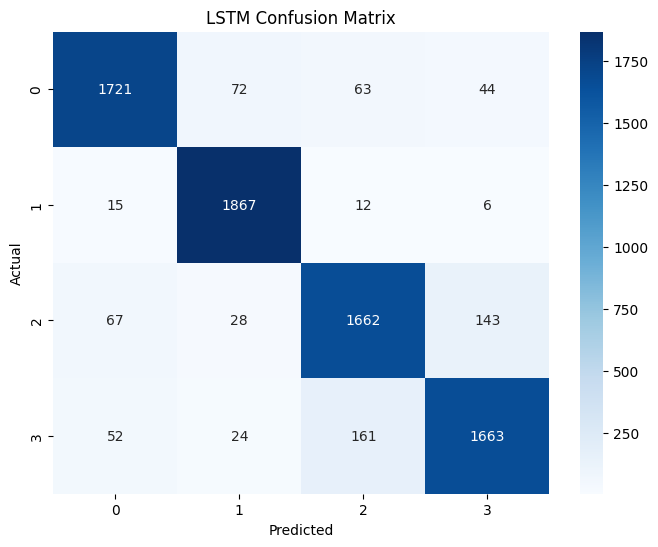

In [ ]:
cm = confusion_matrix(
    y_test,
    pred_lstm
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **Required Visualization 2: Per-Class F1 Score**

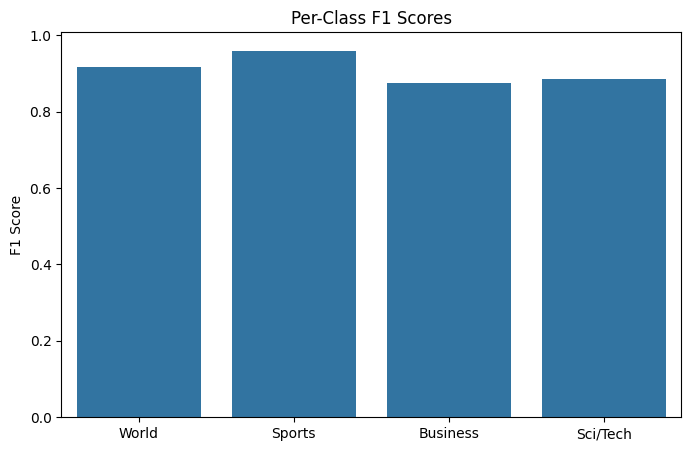

In [ ]:
report = classification_report(
    y_test,
    pred_lstm,
    output_dict=True
)

classes = [
    "World",
    "Sports",
    "Business",
    "Sci/Tech"
]

scores = [
    report['0']['f1-score'],
    report['1']['f1-score'],
    report['2']['f1-score'],
    report['3']['f1-score']
]

plt.figure(figsize=(8,5))

sns.barplot(
    x=classes,
    y=scores
)

plt.title("Per-Class F1 Scores")
plt.ylabel("F1 Score")
plt.show()

## **Required Visualization 3: Training Curves**

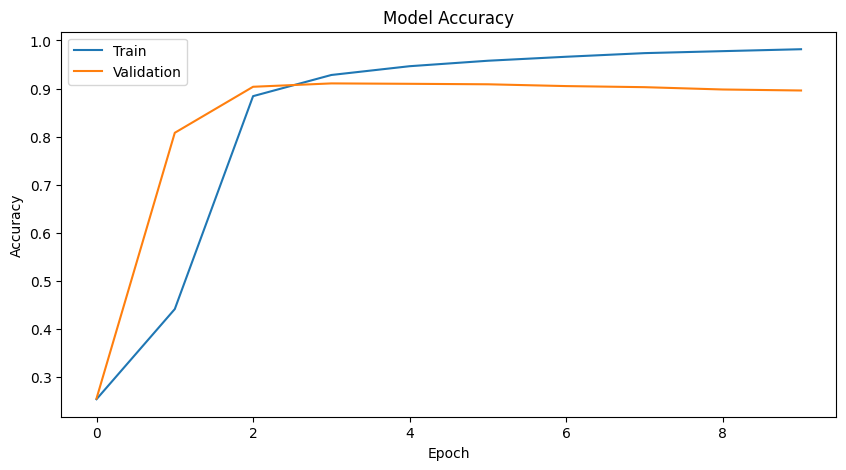

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    'Train',
    'Validation'
])

plt.show()

# **Final Comparison**

In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "TF-IDF + Logistic Regression",
        "Embedding + LSTM"
    ],

    "Macro F1":[
        baseline_f1,
        lstm_f1
    ]
})

print(comparison)

                          Model  Macro F1
0  TF-IDF + Logistic Regression  0.914807
1              Embedding + LSTM  0.909252
